# Modeling

## Setup

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report

In [1]:
!pip install -q scikit-learn-intelex
from sklearnex import patch_sklearn
patch_sklearn()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 MB 8.7 MB/s eta 0:00:00


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Load Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("train.csv")


## Prepare cols

In [4]:
X_train, y_train = train.drop("Survived", axis=1), train["Survived"]
X_test, y_test = test.drop("Survived", axis=1), test["Survived"]

In [6]:
cat_features = ["Title", "Pclass", "Sex", "Age_missing", "Age_bin", "FamilyGroup",
            "TicketPrefix", "Deck", "Embarked", "Cabin_missing"]
num_features = ["FamilySize", "Fare_log"] # "Age"

## Utils

In [44]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def display_confusion_matrix(y, y_pred, labels, title):
  cm = confusion_matrix(y, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=labels)

  plt.figure(figsize=(5,4))
  disp.plot(cmap="Blues", values_format="d")
  plt.title(title)
  plt.show()

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

def perfrom_stratified_cross_val(model, X, y, score="accuracy", n_splits=5):
  cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

  # 1) CV accuracy
  acc = cross_val_score(model, X, y, cv=cv, scoring=score)
  print(f"CV {score}: {acc.mean():.3f} ± {acc.std():.3f}")

  # 2) Out-of-fold predictions for diagnostics
  y_pred_oof = cross_val_predict(model, X, y, cv=cv, method="predict")

  cm = confusion_matrix(y, y_pred_oof)
  disp = ConfusionMatrixDisplay(cm, display_labels=["Died (0)", "Survived (1)"])
  disp.plot(cmap="Blues", values_format="d")
  plt.title("Confusion Matrix (OOF)"); plt.show()

  # (Optional) ROC-AUC with OOF probabilities
  y_proba_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
  print(f"CV ROC-AUC: {roc_auc_score(y, y_proba_oof):.3f}")

## Build preprocessing pipeline

In [9]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

## Models Analysis

### Logistic Regression

CV accuracy: 0.824 ± 0.034


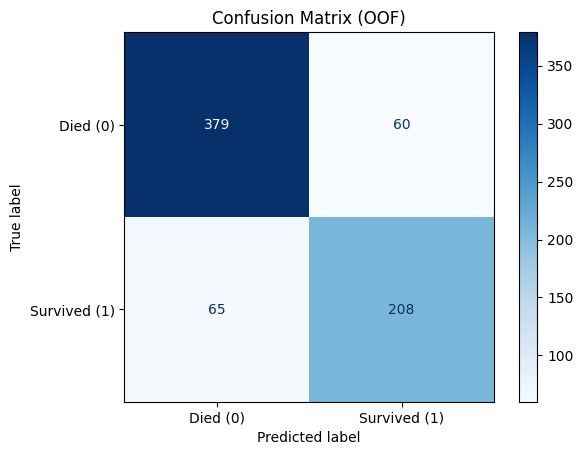

CV ROC-AUC: 0.880


In [39]:
from sklearn.linear_model import LogisticRegression
lr_model = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])
perfrom_stratified_cross_val(lr_model, X_train, y_train)

In [45]:
lr_model.fit(X_train, y_train)
y_pred_test = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

0.8412921348314607
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       439
           1       0.81      0.77      0.79       273

    accuracy                           0.84       712
   macro avg       0.83      0.83      0.83       712
weighted avg       0.84      0.84      0.84       712



<Figure size 500x400 with 0 Axes>

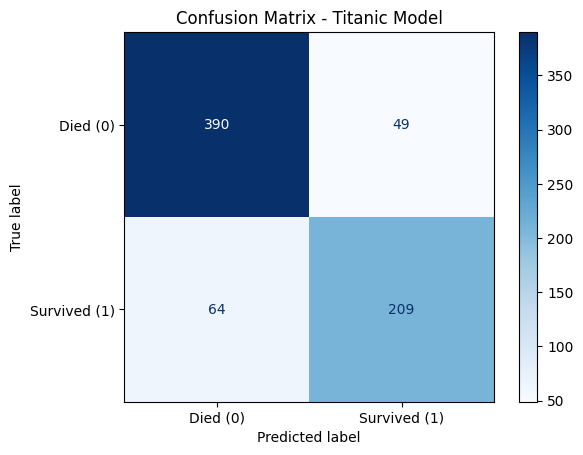

In [46]:
display_confusion_matrix(y_test, y_pred_test,
 ["Died (0)", "Survived (1)"], "Confusion Matrix - Titanic Model")
